In [53]:
import pybamm
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
from scipy import constants
from pybamm import Scalar

current_directory = os.getcwd()

parameter_values = pybamm.ParameterValues("OKane2022") # "lithium plating": "partially reversible",
options = {"thermal": "lumped","lithium plating": "irreversible","SEI":"ec reaction limited", "SEI film resistance":"average", "SEI porosity change": "true","loss of active material": "stress-driven","particle mechanics":"swelling only"} #"lithium plating": "irreversible",


# pybamm.set_logging_level("DEBUG")

In [54]:
model = pybamm.lithium_ion.SPM(options=options) #DFN or SPM

In [55]:
# %load nialldata_tuneparameters.py



In [56]:
# %load std500cycles_tuneparameters.py
#Parameters tuned for 500 cycles standard
parameter_values.update({"Total heat transfer coefficient [W.m-2.K-1]": 10.0,})
#thermal parameters update
parameter_values.update({"Negative electrode OCP entropic change [V.K-1]": -0.0002,
                         "Positive electrode OCP entropic change [V.K-1]": -0.0004,
                         "Contact resistance [Ohm]": 0.001,
                        })
def ec_diffusivity(T_amb):
    D_sj = 2.5e-22*4*10*3*2 
    EaD = 10000
    arrhenius = np.exp(EaD / pybamm.constants.R *(1/ 298.15 - 1/ T_amb))
    return D_sj * arrhenius


parameter_values.update({"EC diffusivity [m2.s-1]": ec_diffusivity})
#sei parameters update
parameter_values.update({"SEI kinetic rate constant [m.s-1]": 1e-12*0.002*0.5}) 
parameter_values.update({"SEI growth activation energy [J.mol-1]": 48000.0,
                         "SEI partial molar volume [m3.mol-1]": 9.585e-05*0.35,
                         "SEI resistivity [Ohm.m]": 200000.0
                         })  
# LAM parameters update

parameter_values.update({"Positive electrode LAM constant proportional term [s-1]": 0.1*0.5*1.5/3600,
                         "Negative electrode LAM constant proportional term [s-1]": 0.17*0.5*1.5/3600,
                         
                         "Positive electrode LAM constant exponential term": 2.0*1.1,
                         "Negative electrode LAM constant exponential term": 2.0*1.1,
                         
                         })





#Plating paremeters update
parameter_values.update({
                        "Lithium plating kinetic rate constant [m.s-1]": 1e-09*0.001,
                        
                        })


## HTC 100 for Niall Base cooling

In [57]:
# #For tuning with base heat cooling for Niall data only
parameter_values.update({"Total heat transfer coefficient [W.m-2.K-1]": 100.0,})

In [58]:
current_directory

'/home/ganmad/batterycode/pybammlocal/PyBaMMlocal/wip'

In [59]:
from itertools import product


temp_list = [10, 25, 40] #25,
# crate_list = [0.33] #,[0.1,0.3, 1]
# soc_list = [100] #,[10, 60, 100] 
# dod_list = [90] #60, 70,[50, 70, 90]

all_cases = list(product(temp_list))

df = pd.DataFrame(all_cases,columns = ["Temperature"])
df.insert(0, "Case", range(1, len(df)+1))
df.to_csv(f"{current_directory}/rev1LinkingPaper2026/compareData/Cases_expdata.csv", index=False)

In [60]:
df

,Case,Temperature
0,1,10
1,2,25
2,3,40


In [61]:
experimentNiall = pybamm.Experiment(
    [
        (
            "Charge at 0.3C until 4.2 V",
            "Hold at 4.2 V until 50 mA",
            "Rest for 4 hours (5 minute period)",
        ) 
    ]+
    [
      
       (
            "Discharge at 1C until 2.5 V",
            "Charge at 0.3C until 4.2 V",
            "Hold at 4.2 V until 50 mA",
        )    
    ]
    * 1200,
    termination= "70% capacity"
    ) 

## Case studies for cyclic ageing

Cycling:   6%|▌         | 71/1201 [00:04<01:07, 16.71it/s]


Took 2.083 s


Cycling:  22%|██▏       | 266/1201 [00:14<00:49, 18.75it/s]


Took 6.974 s


Cycling:  57%|█████▋    | 689/1201 [00:36<00:26, 18.99it/s]


Took 17.035 s


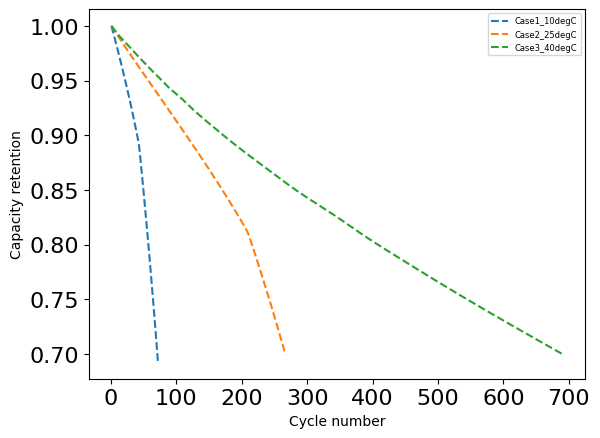

In [62]:
# cycles_per_day = 1
# days_per_year = 365 #365
# years_for_sim = 8
# termination_capacity = 70
# time_per_cycle = 24/cycles_per_day #in hours
# soc_upper_cutoff = 1
# soc_lower_cutoff = 0
# max_dod = soc_upper_cutoff - soc_lower_cutoff
# crate_ref = 0.1
# period_charge_discharge = 5
# period_rest = 60
safe_solver = pybamm.IDAKLUSolver(options={"dt_max": 20}) #options={"dt_max": 10}) #mode="safe", ,  dt_max= dt_max options={"dt_max": 5}

df_conditions = {}
df_conditions = pd.DataFrame(df_conditions)
# simcase_list = []
# experiment_list = []
# no_steps_list = []
# ifcond_cycle_list = []

for n in range(len(df)):
    tempC_case = df["Temperature"][n]
    simcase = df["Case"][n]
    # dod_case = df["DoD"][n]*0.01
    # soc_case = df["SoC"][n]*0.01
    # crate = df["C_rate"][n]
    
    parameter_values.update({"Ambient temperature [K]": 273.15 + tempC_case,
                            "Initial temperature [K]": 273.15 + tempC_case})

     #time in minutes

    # experiment0 = pybamm.Experiment(
    # [
    #     (
    #         f"Charge at {crate}C until 4.2 V",
    #         "Hold at 4.2 V until 50 mA",
    #         "Rest for 10 min (1 minute period)",
    #         f"Discharge at {crate}C until 2.85 V",
    #         "Rest for 20 min (1 minute period)",
    #     )    
    # ]
    # * 1000,
    # termination= "60% capacity"
    # )    

      

    
    
    #exp1 = pybamm.Experiment(list_of_steps_auto*cycles_per_day*days_per_year*years_for_sim, termination=f"{termination_capacity}% capacity")
    sim1 = pybamm.Simulation(model=model, parameter_values=parameter_values, experiment=experimentNiall, solver=safe_solver)
    sol1 = sim1.solve(showprogress=True, ) #save_at_cycles=50
    print("Took", sol1.solve_time)
    
    Q1 = sim1.solution.summary_variables["Capacity [A.h]"]
    cycle1 = sim1.solution.summary_variables["Cycle number"]
    Qpl=  sim1.solution.summary_variables["Loss of capacity to negative lithium plating [A.h]"]

    mlam_n = sim1.solution.summary_variables['Loss of active material in negative electrode [%]']
    mlam_p = sim1.solution.summary_variables['Loss of active material in positive electrode [%]']
    Qlli = sim1.solution.summary_variables['Loss of lithium inventory [%]']
    Qside = sim1.solution.summary_variables["Total capacity lost to side reactions [A.h]"]
    Qsei  = sim1.solution.summary_variables['Loss of capacity to negative SEI [A.h]']
    
    df2 = {}
    df2 = pd.DataFrame(df2)
    df2["Cycle number"] =cycle1
    df2["Capacity Retention"] = Q1/Q1[0]
    df2["LAMpe_per"] =mlam_p
    df2["LAMne_per"] =mlam_n
    df2["Qsei"] = Qsei
    df2["Qpl"] = Qpl
    df2["LLIp"] = Qlli
    df2["Qside"] = Qside


    df2.to_csv(f"{current_directory}/rev1LinkingPaper2026/compareData/Case{simcase}_{tempC_case}degC_sim_dataCompare.csv")

    plt.plot(cycle1,Q1/Q1[0],"--", label =f"Case{simcase}_{tempC_case}degC")  #_{crate}C_{int(soc_case*100)}SoC_{int(dod_case*100)}DoD_{cycles_per_day}cycle")
    plt.legend(fontsize=6)
    
    
    # discharge_time = None
    # charge_time = None
    # rest_time = None
    # discharge_to_soc_time = None
    # list_of_steps_auto = None
    # updated_rest_time = None
    # ifcond_cycle = None
    
    

plt.xlabel("Cycle number")
plt.ylabel("Capacity retention")
plt.xticks(fontsize =16)
plt.yticks(fontsize = 16)
plt.show()



In [ ]:
# t1 = sim1.solution["Time [h]"].entries
# Vc1 = sim1.solution["Terminal voltage [V]"].entries
# Temp1 = sim1.solution["X-averaged cell temperature [K]"].entries

# plt.plot(t1, Vc1)
# plt.show()
# plt.plot(t1, Temp1-273)

In [17]:
root_filepath = "/home/ganmad/batterycode/pybammlocal/PyBaMMlocal/wip/Niall_LGM50data"

if len(root_filepath) > 0:
    root_filepath += '/'
main_data_path = 'Extracted Data - Main/'
DMA_data_path = 'Extracted Data - Degradation Modes/'
timeseries_data_path = 'Timeseries Data from RPTs/'

expt_1_cell_list = ['A', 'E', 'K']
expt_5_cell_list = ['A',  'E', 'F']    # 'B', 'C', 'D', , 'G', 'H'
expt_1_conditions = {cell:temp for cell, temp in zip(expt_1_cell_list, [10]*1 + [25]*1 + [40]*1)}
expt_5_conditions = {cell:temp for cell, temp in zip(expt_5_cell_list, [10]*1 + [25]*1 + [40]*1)}
meta_data_dict = {'Expt 1': {'SoC Range': '0-30',
                             'cell list':expt_1_cell_list,
                             'Temperature dict':expt_1_conditions
                            }, 
                  'Expt 5': {'SoC Range': '0-100',
                             'cell list':expt_5_cell_list,
                             'Temperature dict':expt_5_conditions
                            }
                 }
colour_temp_dict = {10:'C0', 25:'C1', 40:'C3'}

data_dict = {}
for expt in meta_data_dict.keys():
    SoC_range = meta_data_dict[expt]['SoC Range']
    main_data = {}
    DMA_data = {}
    timeseries_data = {}
    for cell in meta_data_dict[expt]['cell list']:
        temp_val = meta_data_dict[expt]['Temperature dict'][cell]
        main_data[cell] = pd.read_csv(f'{root_filepath}{main_data_path}{SoC_range}% SoC/{expt} - cell {cell} ({temp_val}degC) - Extracted Data.csv', index_col=0)
        #DMA_data[cell] = pd.read_csv(f'{root_filepath}{DMA_data_path}{SoC_range}% SoC/cell {cell}/{expt} - DM data from OCV-fitting for cell {cell}.csv', index_col=0)
        # cell_timeseries_data = []
        # for rpt in range(len(main_data[cell])):
        #     if rpt % 2 == 0:
        #         # CC_0p1C = pd.read_csv(f'{root_filepath}{timeseries_data_path}{SoC_range}% SoC/0.1C Voltage Curves/cell {cell}/{expt} - cell {cell} - RPT{rpt} - 0.1C discharge data.csv')
        #         # CC_0p5C = pd.read_csv(f'{root_filepath}{timeseries_data_path}{SoC_range}% SoC/0.5C Voltage Curves/cell {cell}/{expt} - cell {cell} - RPT{rpt} - 0.5C discharge data.csv')
        #         # GITT_25p = pd.read_csv(f'{root_filepath}{timeseries_data_path}{SoC_range}% SoC/GITT Voltage Curves/cell {cell}/{expt} - cell {cell} - RPT{rpt} - 25-pulse GITT 0.5C discharge data.csv')
        #         # GITT_5p = pd.read_csv(f'{root_filepath}{timeseries_data_path}{SoC_range}% SoC/GITT Voltage Curves/cell {cell}/{expt} - cell {cell} - RPT{rpt} - 5-pulse GITT 0.5C discharge data.csv')
        #         # cell_timeseries_data.append([CC_0p1C, CC_0p5C, GITT_25p, GITT_5p])
        #         None
        #     else:
        #         # CC_0p1C = pd.read_csv(f'{root_filepath}{timeseries_data_path}{SoC_range}% SoC/0.1C Voltage Curves/cell {cell}/{expt} - cell {cell} - RPT{rpt} - 0.1C discharge data.csv')
        #         # hybrid_pulse_0p5C = pd.read_csv(f'{root_filepath}{timeseries_data_path}{SoC_range}% SoC/Hybrid CC-Pulse Voltage Curves/cell {cell}/{expt} - cell {cell} - RPT{rpt} - Hybrid CC-Pulse 0.5C discharge data.csv')
        #         # hybrid_pulse_1C = pd.read_csv(f'{root_filepath}{timeseries_data_path}{SoC_range}% SoC/Hybrid CC-Pulse Voltage Curves/cell {cell}/{expt} - cell {cell} - RPT{rpt} - Hybrid CC-Pulse 1C discharge data.csv')
        #         # cell_timeseries_data.append([CC_0p1C, hybrid_pulse_0p5C, hybrid_pulse_1C])
        #         None
        # timeseries_data[cell] = cell_timeseries_data
    data_dict[expt] = {'Main':main_data, 'DMA':DMA_data, 'Timeseries':timeseries_data}

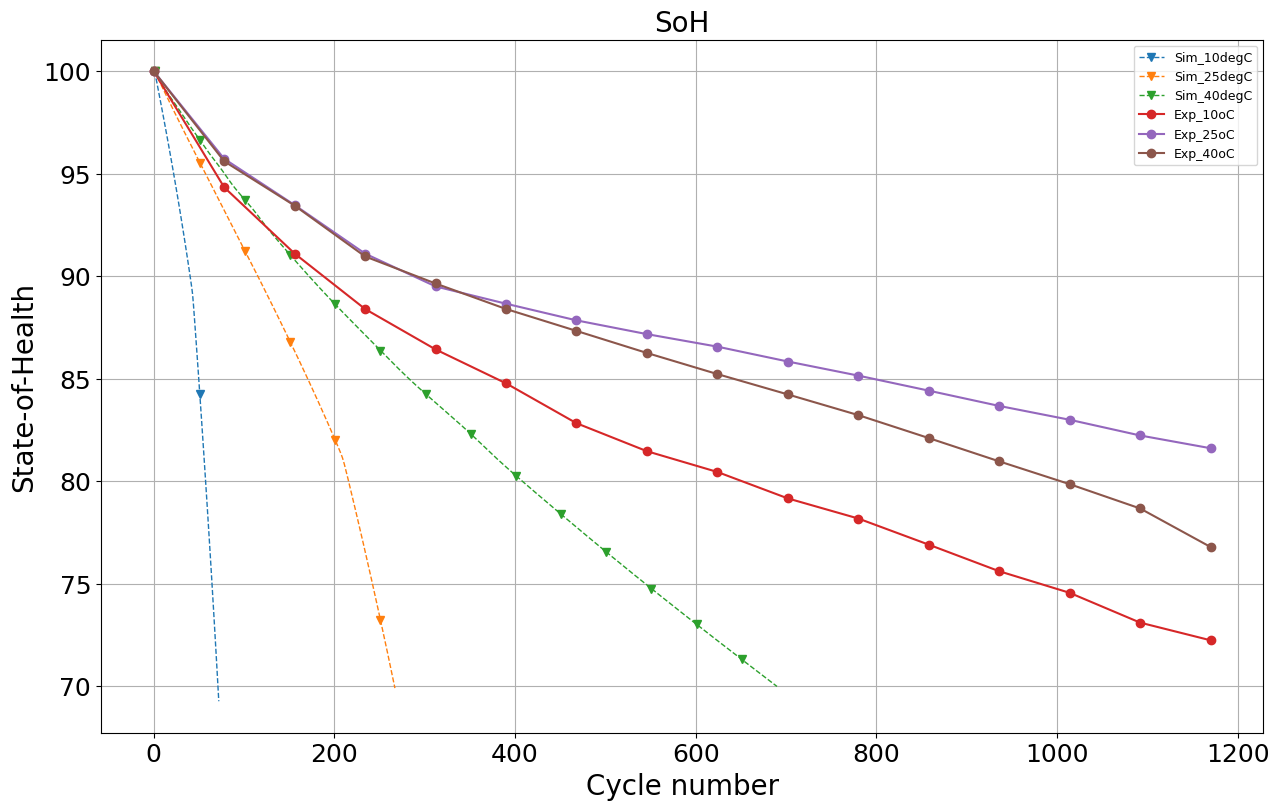

In [63]:
df3 = pd.read_csv(f"{current_directory}/rev1LinkingPaper2026/compareData/Cases_expdata.csv")
cycles_per_day =1
plt.figure(figsize=(15,9))
b =0
for m in range(3):#,29,31,33,35,37,39,43,45,47,49,51,53,59,65,67,69,71,77,81]: #range(27,54):#: #range(5): #
    #b= b+1
    n = m
    tempC_case = df3["Temperature"][n]
    simcase = df3["Case"][n]
    # dod_case = df3["DoD"][n]*0.01
    # soc_case = df3["SoC"][n]*0.01
    # crate = df3["C_rate"][n]
    df4 = pd.read_csv(f"{current_directory}/rev1LinkingPaper2026/compareData/Case{simcase}_{tempC_case}degC_sim_dataCompare.csv")
    plt.plot(df4["Cycle number"], df4["Capacity Retention"]*100, "--", marker='v', markevery=50,linewidth=1, label =f"Sim_{tempC_case}degC") #_{crate}C_{int(soc_case*100)}SoC_{int(dod_case*100)}DoD")

expt = 'Expt 5'
cell = 'E'

x_variable = 'Ageing Cycles'
y_variable_1 = 'C/10 Capacity (mA.h)'
y_variable_2 = '0.1s Resistance (Ohms)'

colours = colour_temp_dict
labels = [f'{temp_value} degC' for temp_value in colour_temp_dict.keys()]

for cell in meta_data_dict[expt]['cell list']:
    temp_val = meta_data_dict[expt]['Temperature dict'][cell]
    soh = data_dict[expt]['Main'][cell][y_variable_1]/data_dict[expt]['Main'][cell][y_variable_1][0]*100
    plt.plot(data_dict[expt]['Main'][cell][x_variable], soh, label = f"Exp_{temp_val}oC", marker='o' )

plt.xlabel('Cycle number',fontsize=20)
plt.ylabel('State-of-Health',fontsize=20)
plt.title('SoH',fontsize=20)
#plt.ylim([70, 102])
#plt.xlim([-50, 1000])
plt.legend(fontsize=9)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.grid(True)
plt.show()

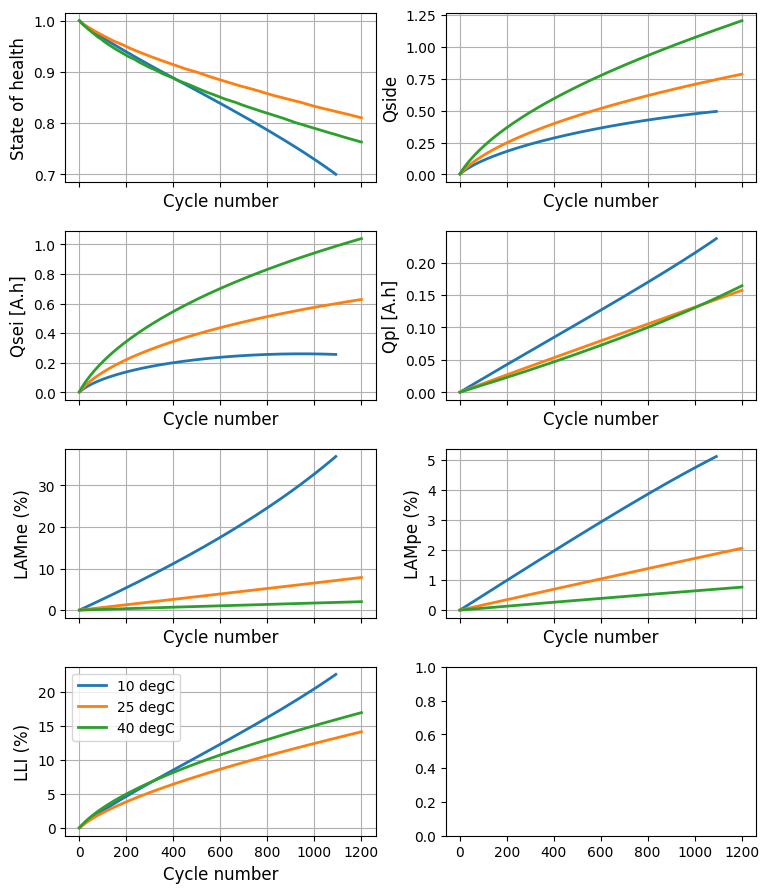

In [78]:
df3 = pd.read_csv(f"{current_directory}/paperstudies2026/tuning/Cases_tuning.csv")
cycles_per_day =1


fig, axes = plt.subplots(4, 2, figsize=(8,9), sharex=True)
axes = axes.flatten()
for m in range(3):#,29,31,33,35,37,39,43,45,47,49,51,53,59,65,67,69,71,77,81]: #range(27,54):#: #range(5): #
   
    n = m
    tempC_case = df3["Temperature"][n]
    simcase = df3["Case"][n]
    dod_case = df3["DoD"][n]*0.01
    soc_case = df3["SoC"][n]*0.01
    crate = df3["C_rate"][n]
    df4 = pd.read_csv(f"{current_directory}/paperstudies2026/tuning/tune_Case{simcase}_{tempC_case}degC_{crate}C_{soc_case*100}SoC_{dod_case*100}DoD_{cycles_per_day}cycle.csv")
    
    xcycle = df4["Cycle number"]
    
    variables = ["Capacity Retention", "Qside", "Qsei", "Qpl", "LAMne_per", "LAMpe_per",  "LLIp", ]
    variables2 = ["State of health", "Qside", "Qsei [A.h]", "Qpl [A.h]", "LAMne (%)", "LAMpe (%)",  "LLI (%)", ]
    
    for i, var in enumerate(variables):

        axes[i].plot(xcycle, df4[var], label = f"{tempC_case} degC", linewidth=2)
        #axes[i].set_title(var)
        
            # X-axis label
        axes[i].set_ylabel(f"{variables2[i]}",fontsize=12)         # Y-axis label
        
        axes[i].set_xlabel("Cycle number", fontsize=12) 
        axes[i].grid(True)
    axes[i].legend()
#plt.xlabel("Cycle number") 

plt.tight_layout()
plt.show()


In [158]:
model.summary_variables

['Time [s]',
 'Time [h]',
 'Throughput capacity [A.h]',
 'Throughput energy [W.h]',
 'Loss of lithium inventory [%]',
 'Loss of lithium inventory, including electrolyte [%]',
 'Total lithium [mol]',
 'Total lithium in electrolyte [mol]',
 'Total lithium in particles [mol]',
 'Total lithium lost [mol]',
 'Total lithium lost from particles [mol]',
 'Total lithium lost from electrolyte [mol]',
 'Loss of lithium to negative SEI [mol]',
 'Loss of capacity to negative SEI [A.h]',
 'Loss of lithium to positive SEI [mol]',
 'Loss of capacity to positive SEI [A.h]',
 'Total lithium lost to side reactions [mol]',
 'Total capacity lost to side reactions [A.h]',
 'Local ECM resistance [Ohm]',
 'Negative electrode capacity [A.h]',
 'Loss of active material in negative electrode [%]',
 'Total lithium in negative electrode [mol]',
 'Loss of lithium to negative lithium plating [mol]',
 'Loss of capacity to negative lithium plating [A.h]',
 'Loss of lithium to negative SEI on cracks [mol]',
 'Loss of c

In [ ]:
#sim1.plot()
#sol1.save("DFN_300cyl_fail-sol.pkl")

In [ ]:
# safe_solver = pybamm.IDAKLUSolver(options={"dt_max": 5}) #mode="safe", ,  dt_max= dt_max, return_solution_if_failed_early=True, dt_max= 5.0,

# parameter_values.update({"Ambient temperature [K]": 298.15,
#                         "Initial temperature [K]": 298.15 })

# sim1 = pybamm.Simulation(model=model, parameter_values=parameter_values, experiment=experiment0, solver=safe_solver) #
# sol1 = sim1.solve(showprogress=True)
# print("Took", sol1.solve_time)







Cycling:  46%|████▌     | 460/1000 [14:23<16:53,  1.88s/it]

Took 13 minutes, 19 seconds


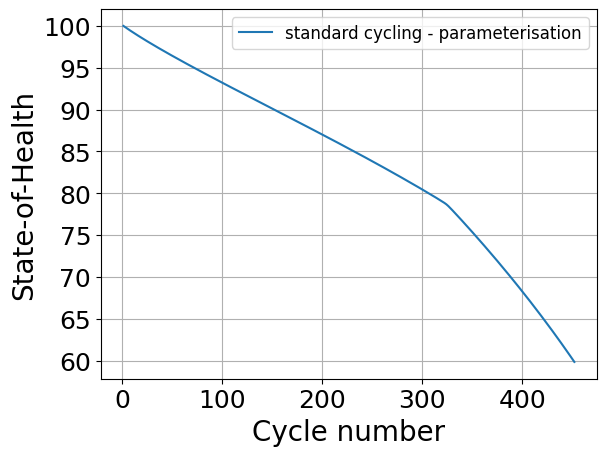

In [14]:
Q1 = sim1.solution.summary_variables["Capacity [A.h]"]
cycle1 = sim1.solution.summary_variables["Cycle number"]
plt.plot(cycle1, 100*(Q1/Q1[0]), label = "standard cycling - parameterisation")
plt.legend(fontsize=12)

plt.xlabel('Cycle number',fontsize=20)
plt.ylabel('State-of-Health',fontsize=20)
# plt.title('SoH of a Lithium-Ion Cell-DFN Model',fontsize=20)
#plt.ylim([75, 101])
# #plt.xlim([-50, 500])
# plt.legend(fontsize=9)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.grid(True)
# plt.show()

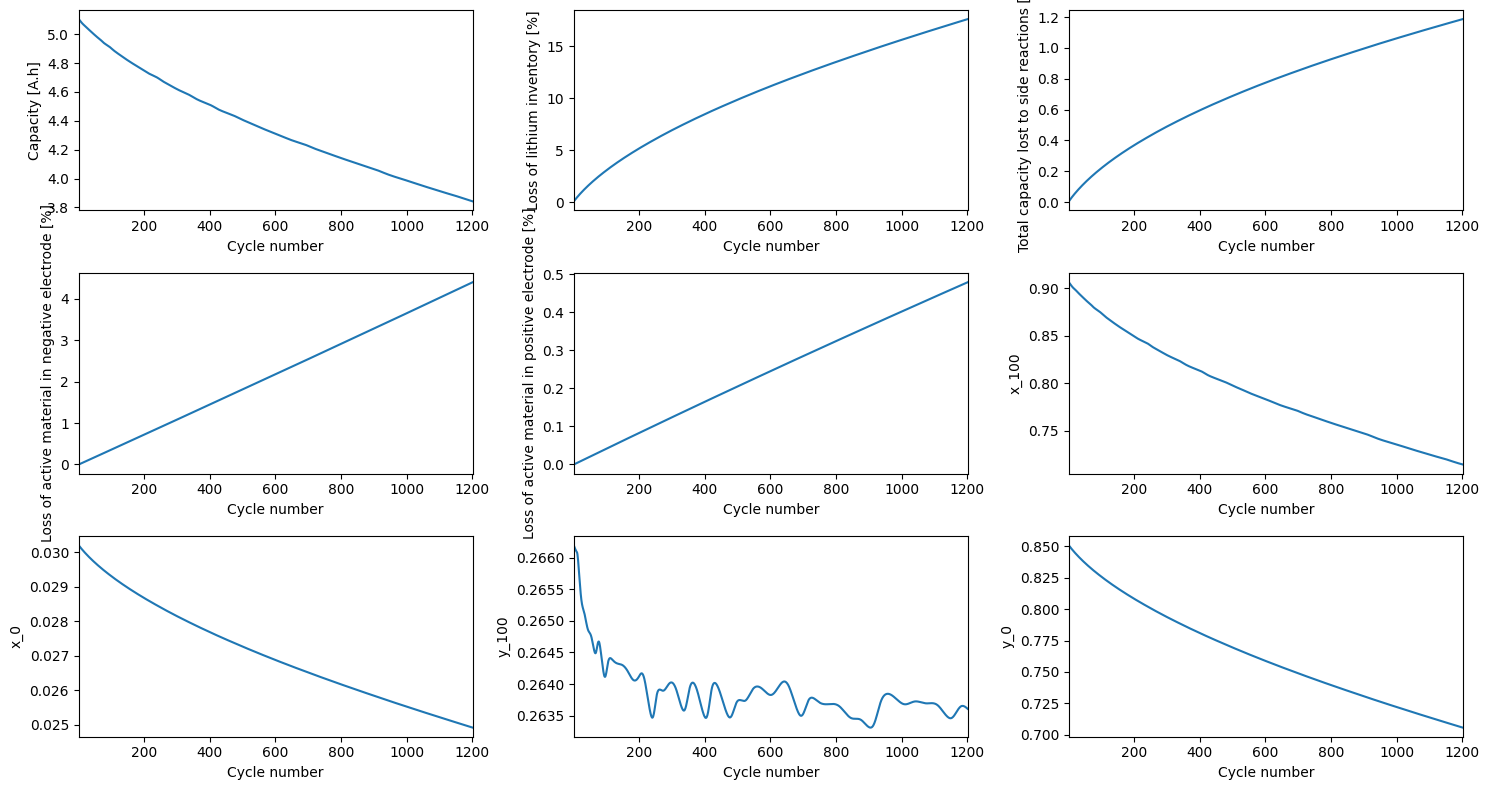

array([[<Axes: xlabel='Cycle number', ylabel='Capacity [A.h]'>,
        <Axes: xlabel='Cycle number', ylabel='Loss of lithium inventory [%]'>,
        <Axes: xlabel='Cycle number', ylabel='Total capacity lost to side reactions [A.h]'>],
       [<Axes: xlabel='Cycle number', ylabel='Loss of active material in negative electrode [%]'>,
        <Axes: xlabel='Cycle number', ylabel='Loss of active material in positive electrode [%]'>,
        <Axes: xlabel='Cycle number', ylabel='x_100'>],
       [<Axes: xlabel='Cycle number', ylabel='x_0'>,
        <Axes: xlabel='Cycle number', ylabel='y_100'>,
        <Axes: xlabel='Cycle number', ylabel='y_0'>]], dtype=object)

In [122]:
pybamm.plot_summary_variables(sim1.solution)

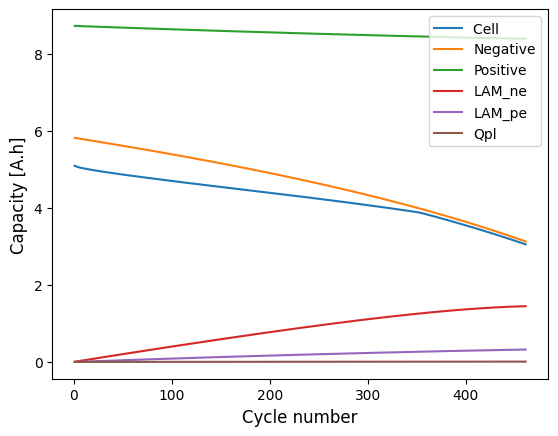

In [ ]:
Q1 = sim1.solution.summary_variables["Capacity [A.h]"]
Qnes = sim1.solution.summary_variables["Negative electrode capacity [A.h]"]
Qpes = sim1.solution.summary_variables["Positive electrode capacity [A.h]"]
Qpl=  sim1.solution.summary_variables["Loss of capacity to negative lithium plating [A.h]"]

mlam_n = sim1.solution.summary_variables['Loss of active material in negative electrode [%]']
mlam_p = sim1.solution.summary_variables['Loss of active material in positive electrode [%]']
cycle1s = sim1.solution.summary_variables["Cycle number"]

r1 = [a*b/100 for a, b in zip(mlam_n,Qnes)]
r2 = [a*b/100 for a, b in zip(mlam_p,Qpes)]
plt.plot(cycle1s, Q1, label="Cell ")
plt.plot(cycle1s, Qnes, label="Negative")
plt.plot(cycle1s, Qpes, label="Positive")
plt.plot(cycle1s, r1, label="LAM_ne")
plt.plot(cycle1s, r2, label="LAM_pe")
plt.plot(cycle1s, Qpl, label="Qpl")

plt.xlabel('Cycle number',fontsize=12)
plt.ylabel('Capacity [A.h]',fontsize=12)
plt.legend()
